# Attention weight analysis — MultiHeadTransformer

Extracts two weight types from the trained model for both the global and obj models.
No HVM neural data is loaded — geometry is read directly from the checkpoint weights.

1. **Temporal attention weights** — softmax attention `w` over CLS + T time tokens from a single dummy forward pass. Reveals the model's intrinsic time preference independent of stimulus.
2. **Neuron importance** — L1 norm of each neuron's column in `input_proj.weight`. Reveals which neurons have the strongest linear projection into the transformer.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, '.')
from config_const import CACHE_DIR, HVM_N_CAT, HVM_TIME_WINDOW, HVM_CATEGORIES
from encoders import MultiHeadTransformer
from encoders.multihead import extract_attn_weights, neuron_importance

cfg_global = json.loads((CACHE_DIR / 'best_hvm_multihead_config.json').read_text())
cfg_obj    = json.loads((CACHE_DIR / 'best_hvm_multihead_obj_config.json').read_text())

def load_model(cfg):
    # Read geometry directly from the checkpoint — no HVM data needed
    ckpt  = torch.load(cfg['checkpoint'], weights_only=False, map_location='cpu')
    state = ckpt['model_state']
    n_neurons = state['input_proj.weight'].shape[1]  # (d_model, N_neurons)
    n_time    = state['pos_embed'].shape[1] - 1       # pos_embed is (1, T+1, d_model)
    m = MultiHeadTransformer(
        n_neurons=n_neurons,
        d_model=int(cfg['d_model']), n_heads=int(cfg['n_heads']),
        n_layers=int(cfg['n_layers']), shared_dim=int(cfg['shared_dim']),
        dropout=0.0, n_categories=HVM_N_CAT,
    )
    m.load_state_dict(state)
    m.eval()
    return m, n_neurons, n_time

model_global, n_neurons, n_time = load_model(cfg_global)
model_obj,    _,         _      = load_model(cfg_obj)

t_start, t_end = HVM_TIME_WINDOW
time_ms = np.linspace(t_start, t_end, n_time, endpoint=False)

print(f'n_neurons={n_neurons}, n_time={n_time}')
print(f'Time axis: {time_ms[0]:.1f} – {time_ms[-1]:.1f} ms  ({len(time_ms)} bins)')
print('Models loaded')

n_neurons=2330, n_time=32
Time axis: 0.0 – 242.2 ms  (32 bins)
Models loaded


/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 1 — Temporal attention weights

The model computes `w = softmax(attn(encoder_output))` of shape `(B, T+1, 1)` where token 0 is the CLS token.
A single forward pass with **zero input** (no HVM data) captures the model's intrinsic temporal preference: which time bins the learned `attn` linear layer up-weights regardless of stimulus content.

In [2]:
attn_global = extract_attn_weights(model_global, HVM_N_CAT)  # (10, T+1)
attn_obj    = extract_attn_weights(model_obj,    HVM_N_CAT)

attn_global_time = attn_global[:, 1:]  # (10, T) — time tokens only
attn_obj_time    = attn_obj[:,    1:]
cls_global = attn_global[:, 0]          # (10,) — CLS token
cls_obj    = attn_obj[:,    0]

print(f'CLS weight — global: {cls_global.mean():.4f} ± {cls_global.std():.4f}  (across categories)')
print(f'CLS weight — obj:    {cls_obj.mean():.4f} ± {cls_obj.std():.4f}')

CLS weight — global: 0.0331 ± 0.0000  (across categories)
CLS weight — obj:    0.0330 ± 0.0000


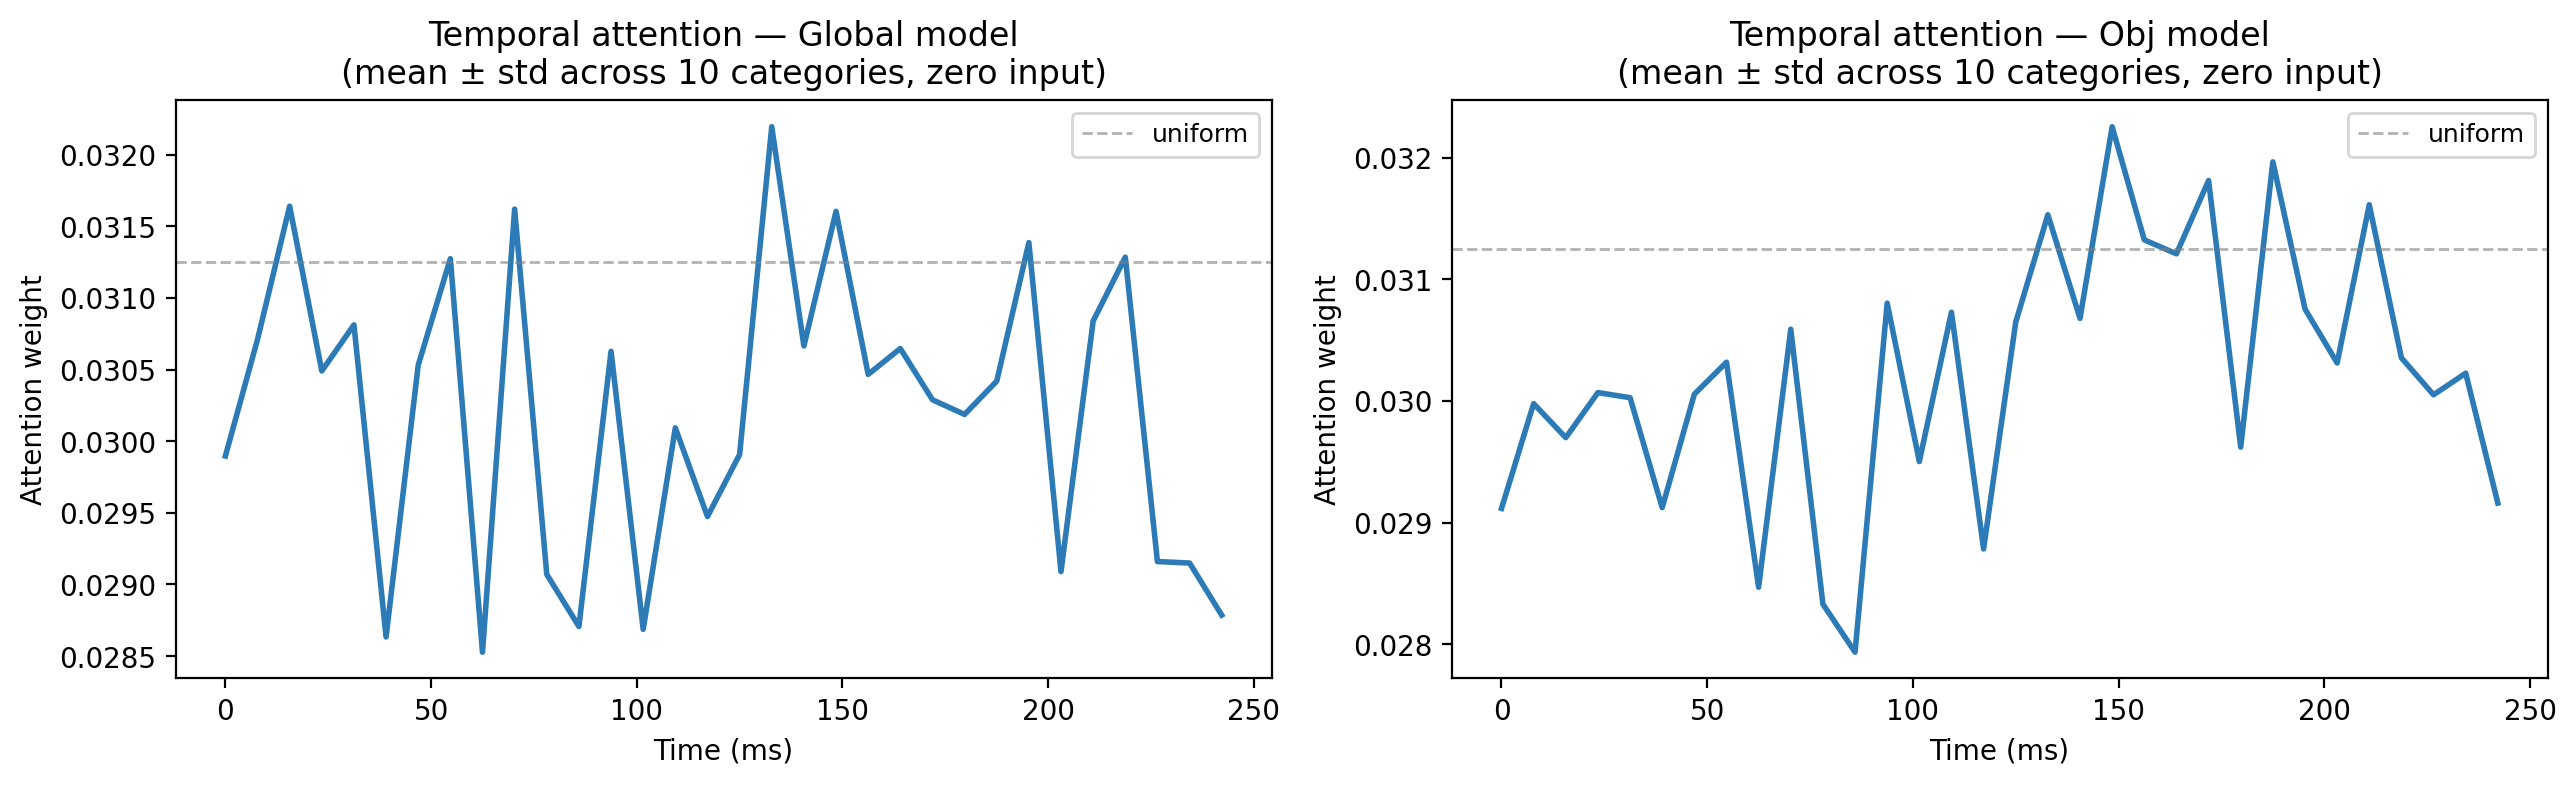

In [3]:
# --- Temporal attention: mean ± std across categories ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, attn_time, label in [
    (axes[0], attn_global_time, 'Global model'),
    (axes[1], attn_obj_time,    'Obj model'),
]:
    mean = attn_time.mean(axis=0)
    std  = attn_time.std(axis=0)
    ax.plot(time_ms, mean, lw=2, color='#2c7bb6')
    ax.fill_between(time_ms, mean - std, mean + std, alpha=0.25, color='#2c7bb6')
    ax.axhline(1 / n_time, color='grey', lw=1, ls='--', alpha=0.6, label='uniform')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Attention weight')
    ax.set_title(f'Temporal attention — {label}\n(mean ± std across 10 categories, zero input)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2 — Neuron importance

`input_proj` maps `(B, T, N_neurons) → (B, T, d_model)` via a weight matrix `W` of shape `(d_model, N_neurons)`.
The L1 norm of column `j` — `‖W[:, j]‖₁` — is the total absolute influence neuron `j` exerts on the transformer's internal representation, independent of input magnitude.

In [4]:
imp_global = neuron_importance(model_global)  # (N_neurons,)
imp_obj    = neuron_importance(model_obj)

print(f'N_neurons={n_neurons}')
print(f'Global — top-10 neuron indices: {np.argsort(imp_global)[-10:][::-1]}')
print(f'Obj    — top-10 neuron indices: {np.argsort(imp_obj)[-10:][::-1]}')

N_neurons=2330
Global — top-10 neuron indices: [ 853 2147 1903  855 2059 2244  774 1882 2077 2146]
Obj    — top-10 neuron indices: [ 853  855 2147 1903 1751 1123 1805 2150 1900 2259]


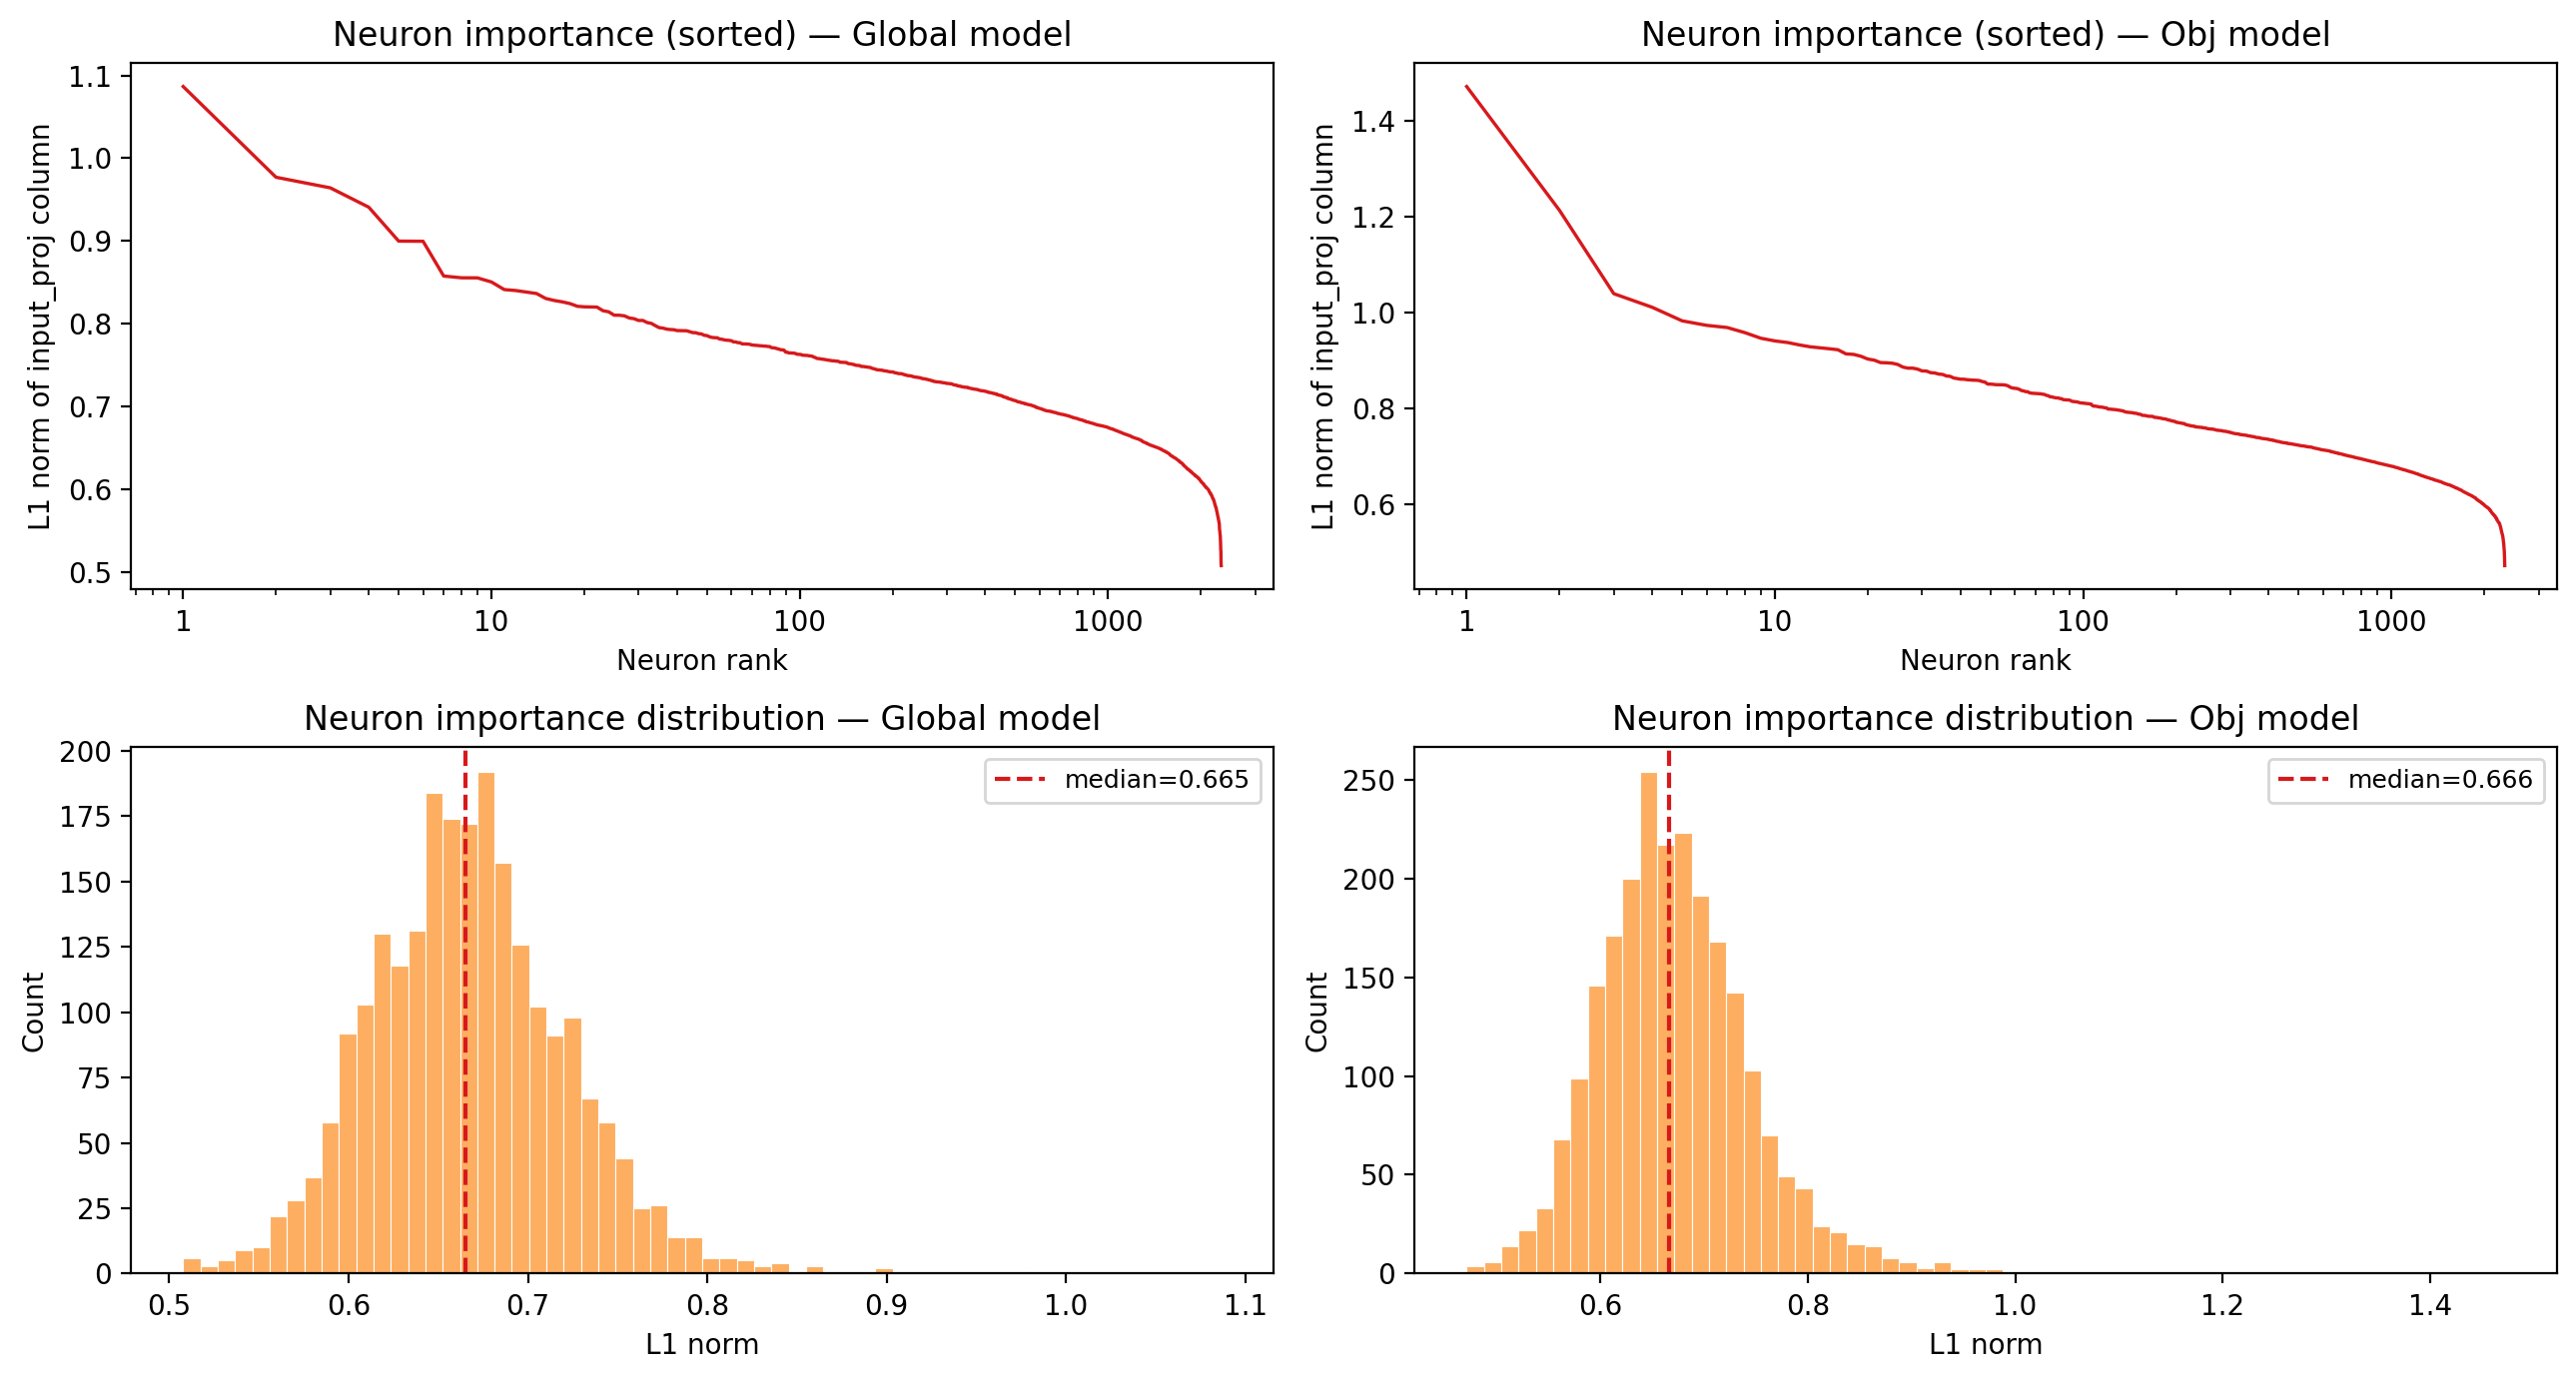

In [5]:
# --- Neuron importance histogram and sorted rank plot ---
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for col, (imp, label) in enumerate([(imp_global, 'Global model'), (imp_obj, 'Obj model')]):
    sorted_imp = np.sort(imp)[::-1]

    # Rank plot
    ax = axes[0, col]
    ax.plot(np.arange(1, n_neurons + 1), sorted_imp, lw=1.2, color='#d7191c')
    ax.set_xlabel('Neuron rank')
    ax.set_ylabel('L1 norm of input_proj column')
    ax.set_title(f'Neuron importance (sorted) — {label}')
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

    # Histogram
    ax = axes[1, col]
    ax.hist(imp, bins=60, color='#fdae61', edgecolor='white', lw=0.4)
    ax.axvline(np.median(imp), color='#d7191c', lw=1.5, ls='--', label=f'median={np.median(imp):.3f}')
    ax.set_xlabel('L1 norm')
    ax.set_ylabel('Count')
    ax.set_title(f'Neuron importance distribution — {label}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

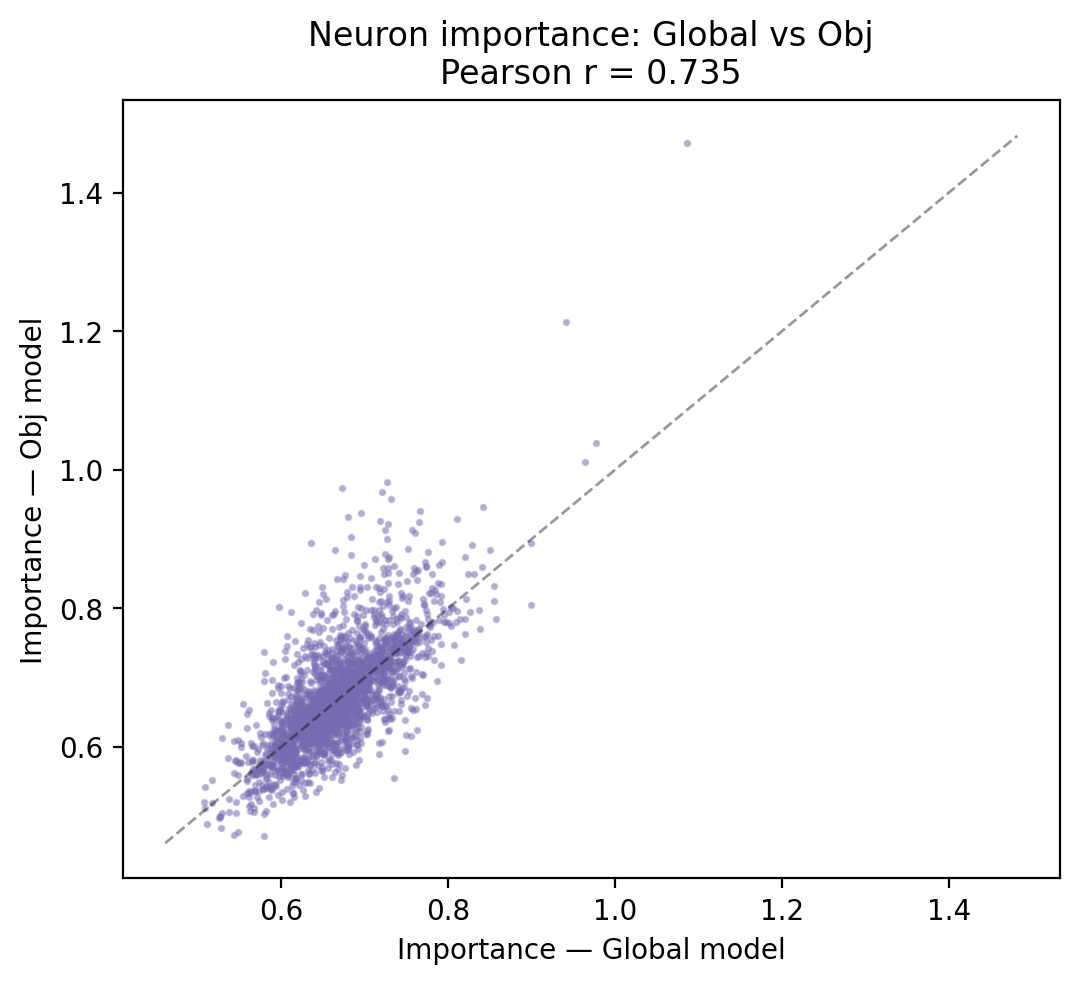

In [6]:
# --- Global vs Obj neuron importance correlation ---
r = np.corrcoef(imp_global, imp_obj)[0, 1]
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(imp_global, imp_obj, s=3, alpha=0.4, color='#756bb1')
lim = [min(imp_global.min(), imp_obj.min()) - 0.01,
       max(imp_global.max(), imp_obj.max()) + 0.01]
ax.plot(lim, lim, 'k--', lw=1, alpha=0.4)
ax.set_xlabel('Importance — Global model')
ax.set_ylabel('Importance — Obj model')
ax.set_title(f'Neuron importance: Global vs Obj\nPearson r = {r:.3f}')
plt.tight_layout()
plt.show()

## 3 — Neuron importance by session and area

`get_neuron_map(dead_mask, monkey_sessions)` maps each neuron back to `(monkey, session, local_idx, area)`.
`_load_hvm_neural` now returns `(rsp, dead_mask, monkey_sessions)` so the session list is free — no extra data loading needed.

In [7]:
import gc
from HexPred.object_response.get_hvm_response import extract_hvm_data
from data_utils.hvm_loader import _load_hvm_neural, get_neuron_map

# _load_hvm_neural now returns (rsp, dead_mask, monkey_sessions) —
# the sessions come free from the same get_hvm_responses calls already made inside.
rsp, dead_mask, monkey_sessions = _load_hvm_neural()
del rsp
extract_hvm_data.cache_clear()
gc.collect()

neuron_map = get_neuron_map(dead_mask, monkey_sessions)
print(f'Mapped {len(neuron_map)} surviving neurons  ({dead_mask.sum()} dead dropped)')
assert len(neuron_map) == n_neurons, f"Map length {len(neuron_map)} != n_neurons {n_neurons}"
print('Length matches checkpoint n_neurons ✓')

Loading HVM sessions: 100%|██████████| 10/10 [00:42<00:00,  4.27s/it]


Mapped 2330 surviving neurons  (0 dead dropped)
Length matches checkpoint n_neurons ✓


Neurons per area:
area
HC          53
PHC        129
PRH         14
TE0        664
TE2        381
TE3        565
WM          94
unknown    430



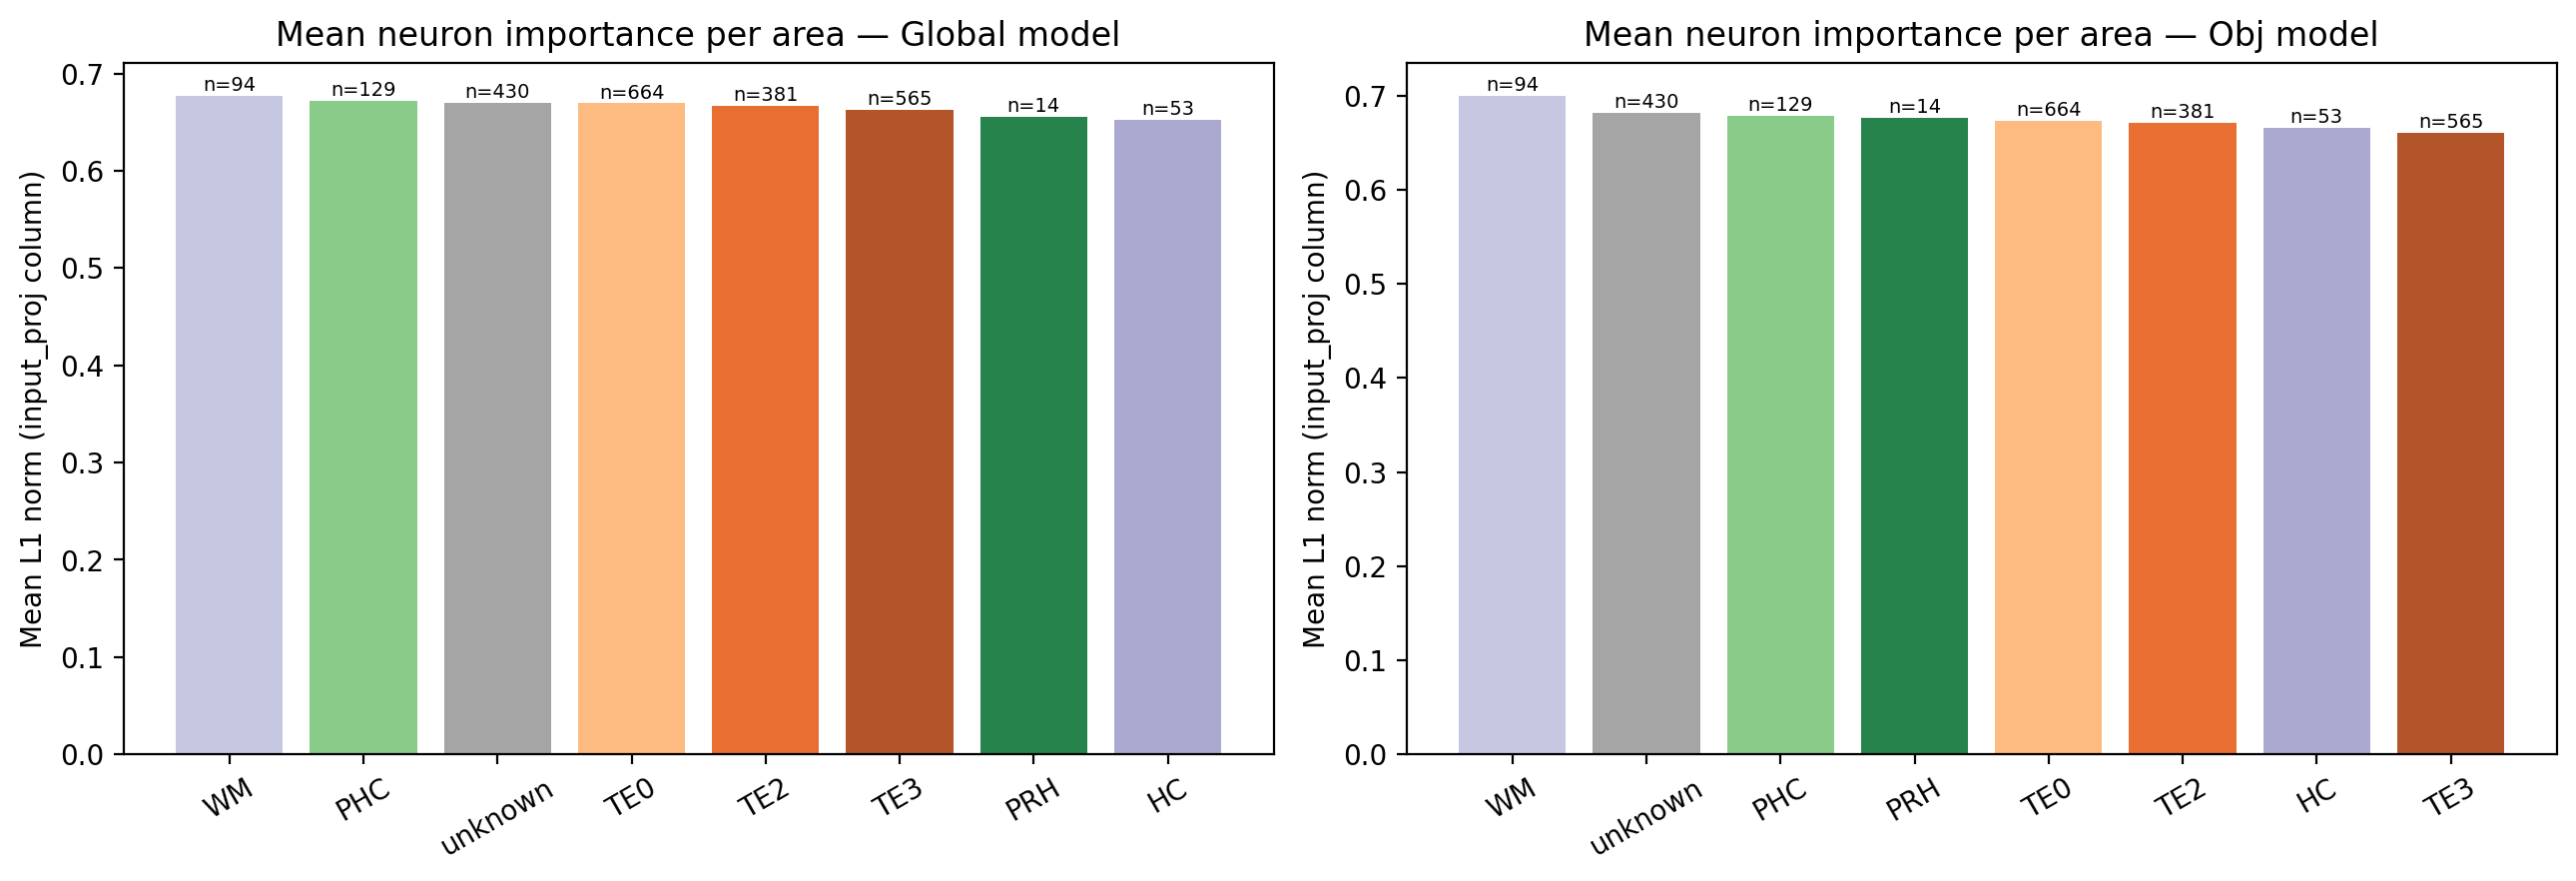

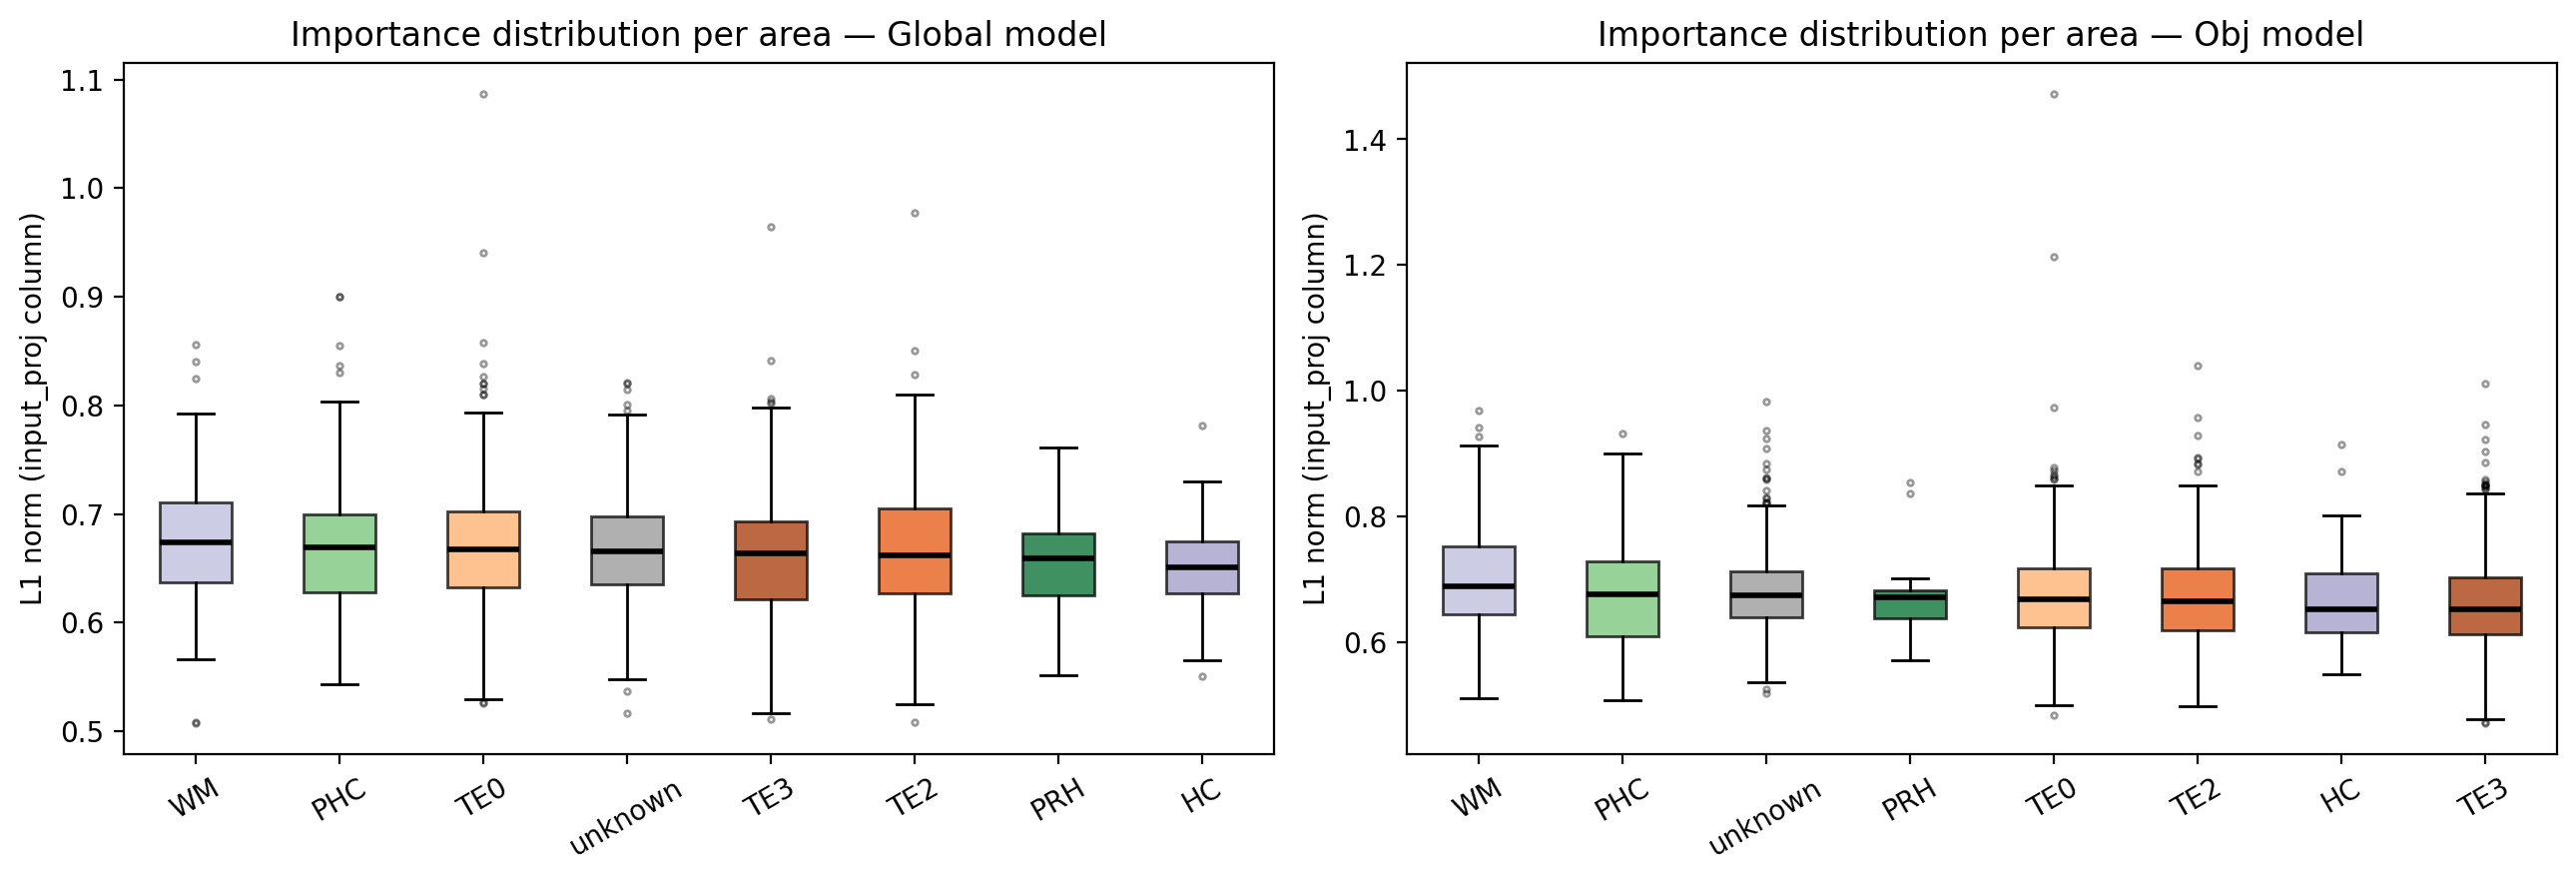

In [8]:
import pandas as pd

df = pd.DataFrame(neuron_map)   # columns: monkey, session, local_idx, area
df['imp_global'] = imp_global
df['imp_obj']    = imp_obj

# --- Mean importance per area ---
area_global = df.groupby('area')['imp_global'].mean().sort_values(ascending=False)
area_obj    = df.groupby('area')['imp_obj'].mean().sort_values(ascending=False)
area_count  = df.groupby('area').size().rename('count')

print('Neurons per area:')
print(area_count.to_string())
print()

AREA_COLORS = {
    'V2':        '#9ecae1',
    'V3':        '#3182bd',
    'TE0':       '#fdae6b',
    'TE2':       '#e6550d',
    'TE3':       '#a63603',
    'PHC':       '#74c476',
    'ENT':       '#238b45',
    'PRH':       '#006d2c',
    'HC':        '#9e9ac8',
    'WM':        '#bcbddc',
    'Ventricle': '#d9d9d9',
    'unknown':   '#969696',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, area_imp, label in [
    (axes[0], area_global, 'Global model'),
    (axes[1], area_obj,    'Obj model'),
]:
    areas_sorted = area_imp.index.tolist()
    counts = [area_count.get(a, 0) for a in areas_sorted]
    colors = [AREA_COLORS.get(a, '#969696') for a in areas_sorted]
    bars = ax.bar(areas_sorted, area_imp.values, color=colors, alpha=0.85)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'n={c}', ha='center', va='bottom', fontsize=7)
    ax.set_ylabel('Mean L1 norm (input_proj column)')
    ax.set_title(f'Mean neuron importance per area — {label}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# --- Per-area importance distribution (boxplot) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, label in [
    (axes[0], 'imp_global', 'Global model'),
    (axes[1], 'imp_obj',    'Obj model'),
]:
    area_order = df.groupby('area')[col].median().sort_values(ascending=False).index.tolist()
    data = [df.loc[df['area'] == a, col].values for a in area_order]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4))
    for patch, area in zip(bp['boxes'], area_order):
        patch.set_facecolor(AREA_COLORS.get(area, '#969696'))
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(area_order) + 1))
    ax.set_xticklabels(area_order, rotation=30)
    ax.set_ylabel('L1 norm (input_proj column)')
    ax.set_title(f'Importance distribution per area — {label}')

plt.tight_layout()
plt.show()

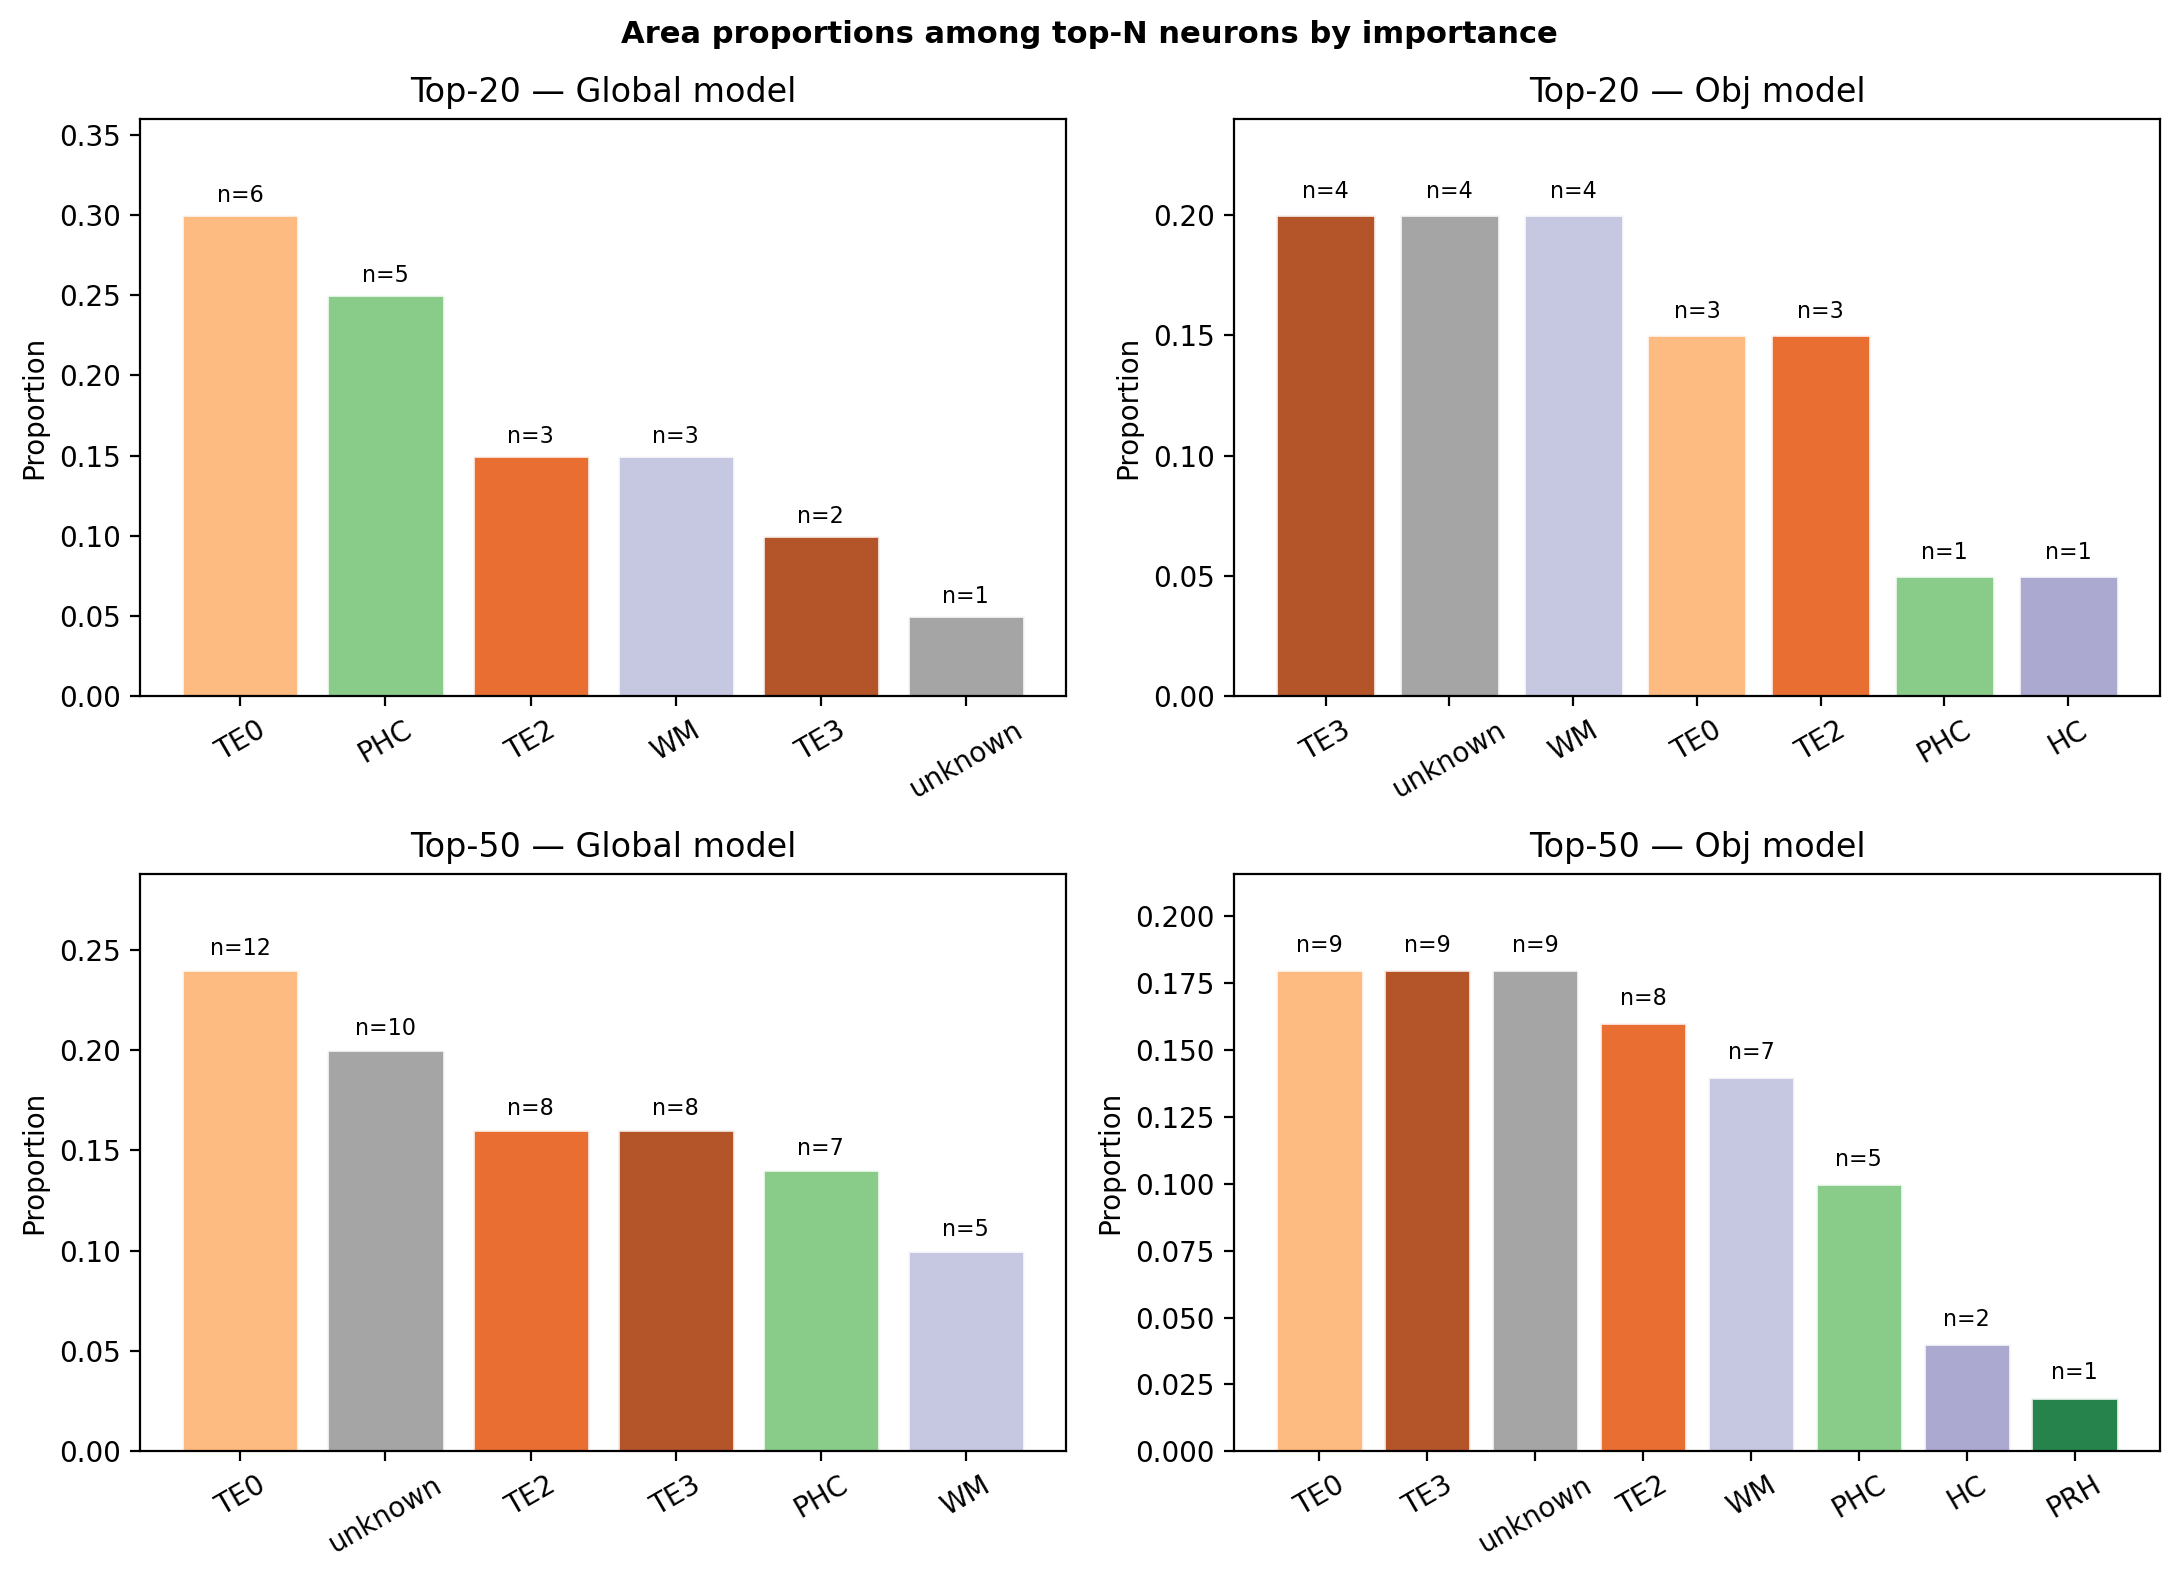


Top-20 neurons — Global model
         monkey                       session  local_idx     area  imp_global
rank                                                                         
1     Bourgeois  Bourgeois_20241126_R_H00_P21         99      TE0    1.086645
2     Bourgeois  Bourgeois_20250325_R_H01_P28        154      TE2    0.977039
3     Bourgeois  Bourgeois_20250128_R_H00_P54        233      TE3    0.964241
4     Bourgeois  Bourgeois_20241126_R_H00_P21        101      TE0    0.940840
5     Bourgeois  Bourgeois_20250325_R_H01_P28         23      PHC    0.899865
6     Bourgeois  Bourgeois_20250508_R_H01_P49        128      PHC    0.899670
7     Bourgeois  Bourgeois_20241126_R_H00_P21         20      TE0    0.857663
8     Bourgeois  Bourgeois_20250128_R_H00_P54        177       WM    0.855532
9     Bourgeois  Bourgeois_20250325_R_H01_P28         72      PHC    0.855467
10    Bourgeois  Bourgeois_20250325_R_H01_P28        153      TE2    0.850502
11    Bourgeois  Bourgeois_202501

In [9]:
# --- Top-N area proportion plots ---
TOP_NS = [20, 50]
fig, axes = plt.subplots(len(TOP_NS), 2, figsize=(11, 4 * len(TOP_NS)))

for row, top_n in enumerate(TOP_NS):
    for col, (imp_col, label) in enumerate([('imp_global', 'Global model'), ('imp_obj', 'Obj model')]):
        ax = axes[row, col]
        top = df.nlargest(top_n, imp_col)
        counts = top['area'].value_counts()
        proportions = counts / top_n
        colors = [AREA_COLORS.get(a, '#969696') for a in proportions.index]
        bars = ax.bar(proportions.index, proportions.values, color=colors, alpha=0.85, edgecolor='white')
        for bar, n in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f'n={n}', ha='center', va='bottom', fontsize=8)
        ax.set_ylim(0, proportions.max() * 1.2)
        ax.set_ylabel('Proportion')
        ax.set_title(f'Top-{top_n} — {label}')
        ax.tick_params(axis='x', rotation=30)

fig.suptitle('Area proportions among top-N neurons by importance', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Print tables ---
for imp_col, label in [('imp_global', 'Global'), ('imp_obj', 'Obj')]:
    top20 = df.nlargest(20, imp_col)[['monkey', 'session', 'local_idx', 'area', imp_col]]
    top20.index = range(1, 21)
    top20.index.name = 'rank'
    print(f'\nTop-20 neurons — {label} model')
    print(top20.to_string())